# CVDMS HRTEM Simulation

This notebook demonstrates HRTEM (high-resolution transmission electron microscopy)
simulation using the CVDMS algorithm in abTEM, with backscattering (BSC) correction
and frozen phonon averaging.

## Contents
1. Setup and crystal structure
2. Reference: Fourier multislice HRTEM
3. CVDMS HRTEM without backscattering
4. CVDMS HRTEM with backscattering (conj mode)
5. Frozen phonon HRTEM
6. CTF application and image formation
7. Backscattering diffraction (FP ensemble)
8. Backscattered wave analysis (FP ensemble)
9. BSC depth profile (per config + FP avg)
10. Comparison and discussion

## 1. Setup

In [1]:
import abtem
import ase
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
from ase.spacegroup import crystal
from abtem import (
    PlaneWave, Potential, CTF, FrozenPhonons,
    Waves, show_atoms, standardize_cell,
)
from abtem.multislice import (
    CVDMSMultislice, FourierMultislice,
    multislice_and_detect,
)
from abtem.core import config as _cfg

# Device and FFT configuration
_cfg.set({"device": "gpu", "fft": "cupy"})

# GPU memory helper: call between heavy cells to prevent OOM in notebook
def _cleanup_gpu():
    import gc
    gc.collect()
    cp.get_default_memory_pool().free_all_blocks()

## 2. Crystal Structure

We use SrTiO₃ (100) as a test specimen. A supercell is created for
the HRTEM simulation.

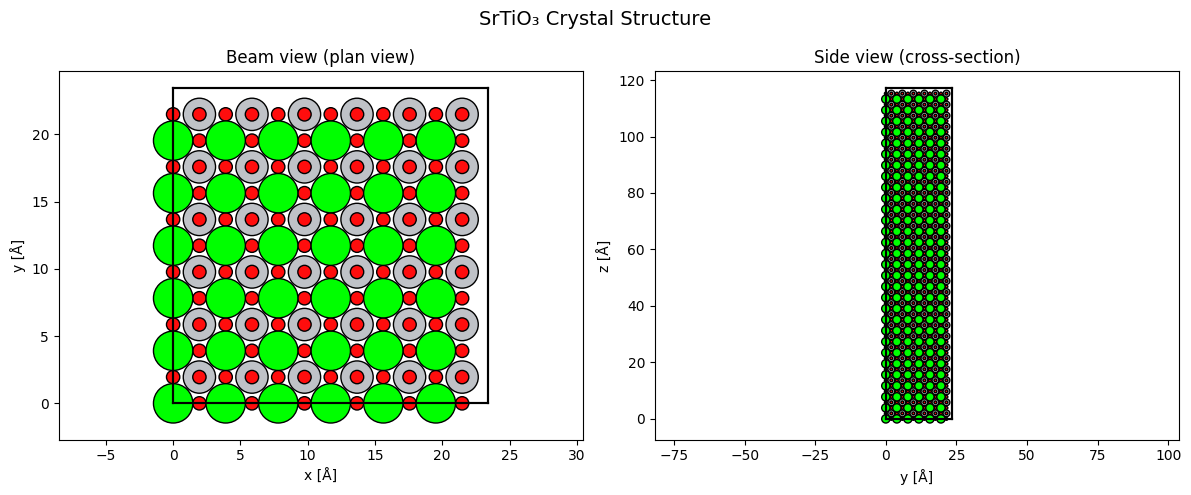

In [2]:
# Build SrTiO₃ supercell
atoms = crystal(
    ["Sr", "Ti", "O"],
    basis=[(0, 0, 0), (0.5, 0.5, 0.5), (0.5, 0.5, 0)],
    spacegroup=221,
    cellpar=[3.905, 3.905, 3.905, 90, 90, 90],
)
atoms *= (6, 6, 30)  # supercell for HRTEM

# Visualize the structure (use the supercell for display)
atoms_display = atoms.copy()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
show_atoms(atoms_display, plane="xy", ax=ax1, title="Beam view (plan view)")
show_atoms(atoms_display, plane="yz", ax=ax2, title="Side view (cross-section)")
fig.suptitle("SrTiO₃ Crystal Structure", fontsize=14)
plt.tight_layout()
plt.show()

## 3. Potential Setup

In [3]:
# Note: BSC back-propagation requires at least 2 exit planes
# (entrance surface + final). Set exit_planes to an integer > 0.
# With exit_planes=50, exit planes are placed every ~20 Å.
# Larger spacing reduces GPU memory for thick specimens.
EXIT_PLANES = 30
sampling = 0.1  # Å/pixel
slice_thickness = 1  # Å/slice
convergence_threshold = 1e-7  # for multislice convergence


# Potential with frozen phonon support
frozen_phonons = FrozenPhonons(atoms, num_configs=8, sigmas=0.085)
potential = Potential(
    frozen_phonons,
    sampling=sampling,         # Å/pixel
    slice_thickness=slice_thickness,   # Å/slice
    exit_planes=EXIT_PLANES,
)

print(f"Number of frozen phonon configurations: {frozen_phonons.num_configs}")
print(f"Number of potential slices: {len([sl for sl in potential])}")
print(f"Number of exit planes: {potential.num_exit_planes}")
print(f"Total thickness: {len([sl for sl in potential]) * slice_thickness:.1f} Å")

# Also create a single-configuration potential for quick tests
single_potential = Potential(
    atoms,
    sampling=sampling,
    slice_thickness=slice_thickness,
    exit_planes=EXIT_PLANES,
)

Number of frozen phonon configurations: 8
Number of potential slices: 118
Number of exit planes: 5
Total thickness: 118.0 Å


## 4. Plane Wave Setup

In [4]:
plane_wave = PlaneWave(energy=300e3)  # 30 keV
print(f"Plane wave energy: {plane_wave.energy:.0f} eV")
print(f"Wavelength: {plane_wave.wavelength:.4f} Å")

Plane wave energy: 300000 eV
Wavelength: 0.0197 Å


## 5. Reference: Fourier Multislice HRTEM

First, compute a reference HRTEM exit wave using the standard
Fourier multislice method, without backscattering.

In [5]:
print("Computing Fourier reference (no BSC)...")
exit_wave_fresnel = plane_wave.multislice(
    single_potential,
    algorithm=FourierMultislice(),
    lazy=False,
)
print(f"Exit wave shape: {exit_wave_fresnel.shape}")

# Use the final exit plane for display
final_ep = -1
print(f"Final exit plane slice: {exit_wave_fresnel.shape[0] + final_ep}")

Computing Fourier reference (no BSC)...
Exit wave shape: (5, 235, 235)
Final exit plane slice: 4


In [6]:
_cleanup_gpu()

## 6. CVDMS HRTEM Without Backscattering

Next, compute the HRTEM exit wave using the CVDMS algorithm
without backscattering correction for direct comparison.

In [7]:
print("Computing CVDMS reference (no BSC)...")
exit_wave_cvdms = plane_wave.multislice(
    single_potential,
    algorithm=CVDMSMultislice(
        convergence_threshold=convergence_threshold,
        order=1,
    ),
    lazy=False,
)
print(f"Exit wave shape: {exit_wave_cvdms.shape}")

Computing CVDMS reference (no BSC)...
[cvdms] Using C++ CUDA backend
Exit wave shape: (5, 235, 235)


In [8]:
_cleanup_gpu()

## 7. CVDMS HRTEM With Backscattering

Compute the HRTEM exit wave with full CVDMS backscattering correction,
using both the physically correct conj mode and the CGS-compatible forward mode.

The backscattering correction subtracts the backscattered component from the
forward wave at each slice interface, accounting for energy loss to
backscattered electrons.

In [9]:
print("Computing CVDMS + BSC (conj mode)...")
result_bsc_conj = plane_wave.multislice(
    single_potential,
    algorithm=CVDMSMultislice(
        backscattering=True,
        calculate_backscattered=True,
        back_prop_mode="conj",
        convergence_threshold=convergence_threshold,
        order=1,
    ),
    return_backscattered=True,
    lazy=False,
)
exit_wave_bsc_conj = result_bsc_conj[0]     # forward exit wave
bsc_wave_conj = result_bsc_conj[-1]          # backscattered wave
print(f"Exit wave shape: {exit_wave_bsc_conj.shape}")
print(f"BSC wave shape: {bsc_wave_conj.shape}")
print(f"BSC max amplitude: {float(np.abs(bsc_wave_conj.array).max()):.4e}")

Computing CVDMS + BSC (conj mode)...
Exit wave shape: (5, 235, 235)
BSC wave shape: (5, 235, 235)
BSC max amplitude: 2.2026e-03


In [10]:
print("Computing CVDMS + BSC (forward mode)...")
result_bsc_fwd = plane_wave.multislice(
    single_potential,
    algorithm=CVDMSMultislice(
        backscattering=True,
        calculate_backscattered=True,
        back_prop_mode="forward",
        convergence_threshold=convergence_threshold,
        order=1,
    ),
    return_backscattered=True,
    lazy=False,
)
exit_wave_bsc_fwd = result_bsc_fwd[0]
bsc_wave_fwd = result_bsc_fwd[-1]
print(f"Exit wave shape: {exit_wave_bsc_fwd.shape}")
print(f"BSC wave shape: {bsc_wave_fwd.shape}")
print(f"BSC max amplitude: {float(np.abs(bsc_wave_fwd.array).max()):.4e}")

Computing CVDMS + BSC (forward mode)...
Exit wave shape: (5, 235, 235)
BSC wave shape: (5, 235, 235)
BSC max amplitude: 1.6640e-02


## 8. Compare Exit Waves

Compute the difference between the Fourier, CVDMS (no BSC), and CVDMS + BSC results.
This shows the effect of the CVDMS algorithm and backscattering correction on
the exit wave.

Exit wave comparisons:
  |Fourier - CVDMS (no BSC)| max = 9.0951e-01
  |CVDMS (no BSC) - CVDMS + BSC| max = 2.4586e-03


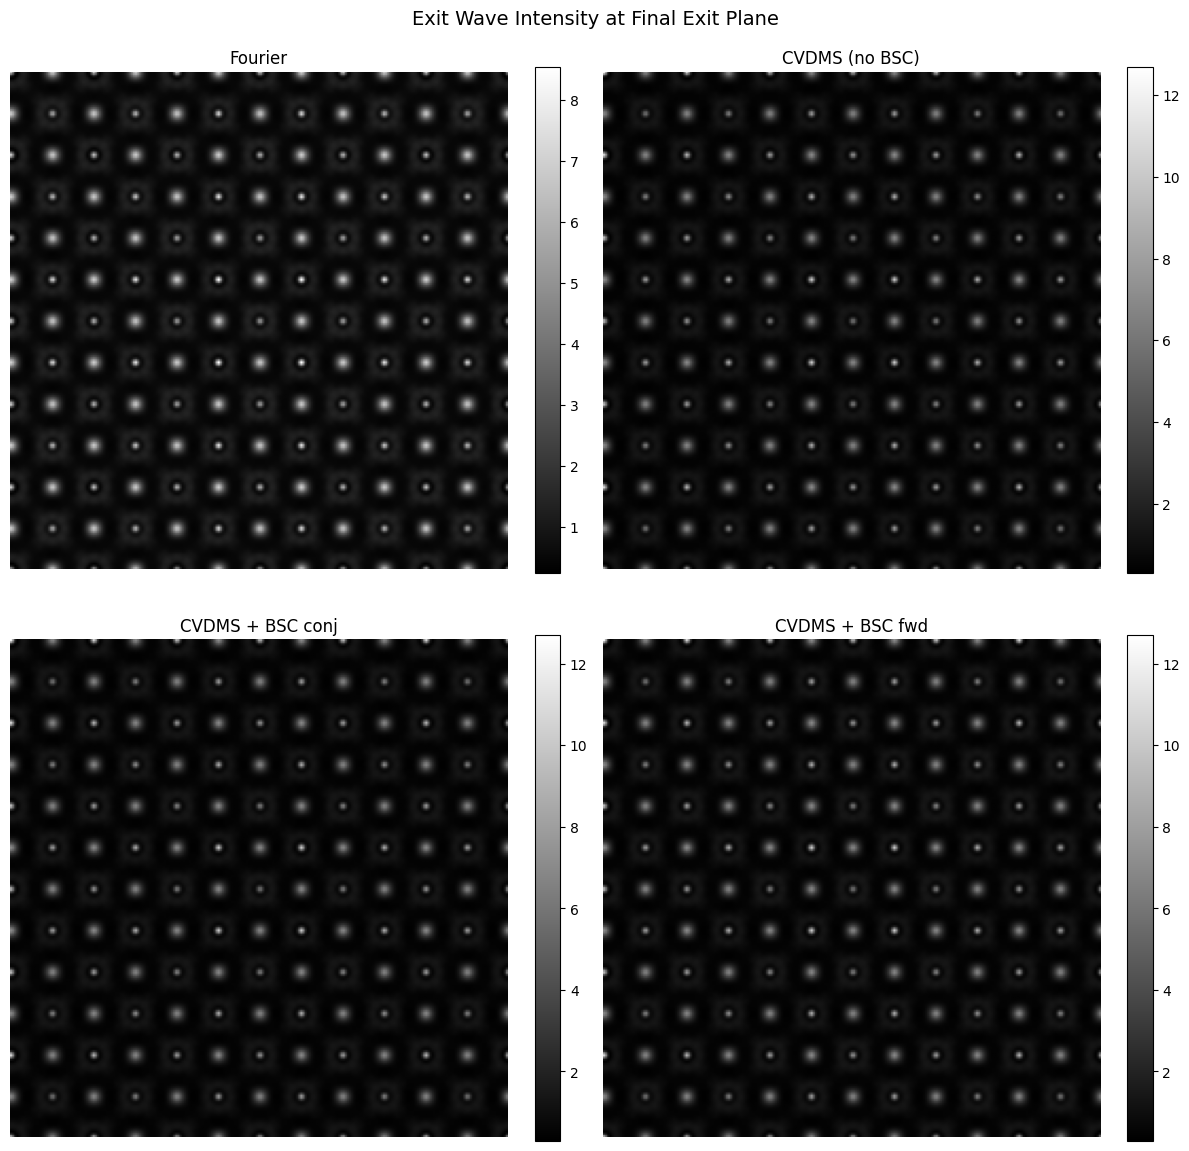

In [11]:
# Compute differences
diff_fresnel_cvdms = np.abs(exit_wave_fresnel.array - exit_wave_cvdms.array)
diff_cvdms_bsc = np.abs(exit_wave_cvdms.array - exit_wave_bsc_conj.array)

print("Exit wave comparisons:")
print(f"  |Fourier - CVDMS (no BSC)| max = {float(diff_fresnel_cvdms.max()):.4e}")
print(f"  |CVDMS (no BSC) - CVDMS + BSC| max = {float(diff_cvdms_bsc.max()):.4e}")

# Visualize exit wave intensity at the final exit plane
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

methods = [
    ("Fourier", exit_wave_fresnel),
    ("CVDMS (no BSC)", exit_wave_cvdms),
    ("CVDMS + BSC conj", exit_wave_bsc_conj),
    ("CVDMS + BSC fwd", exit_wave_bsc_fwd),
]

def get_cpu_intensity(wave):
    """Extract final exit plane intensity as CPU numpy array."""
    arr = wave.array[-1]  # final exit plane
    if hasattr(arr, 'get'):
        arr = arr.get()
    return np.abs(arr) ** 2

for (name, wave), ax in zip(methods, axes.ravel()):
    intensity = get_cpu_intensity(wave)
    im = ax.imshow(intensity, cmap="gray")
    ax.set_title(name)
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046)

fig.suptitle("Exit Wave Intensity at Final Exit Plane", fontsize=14)
plt.tight_layout()
plt.show()

## 9. CTF Application and HRTEM Image Formation

Apply the contrast transfer function (CTF) to the exit waves to form
HRTEM images. We include spherical aberration (Cs), objective aperture,
and partial coherence (focal spread).

Scherzer defocus: -48.61 Å
Crossover angle: 34.86 mrad
Point resolution: 0.56 Å
Focal spread: 14.00 Å


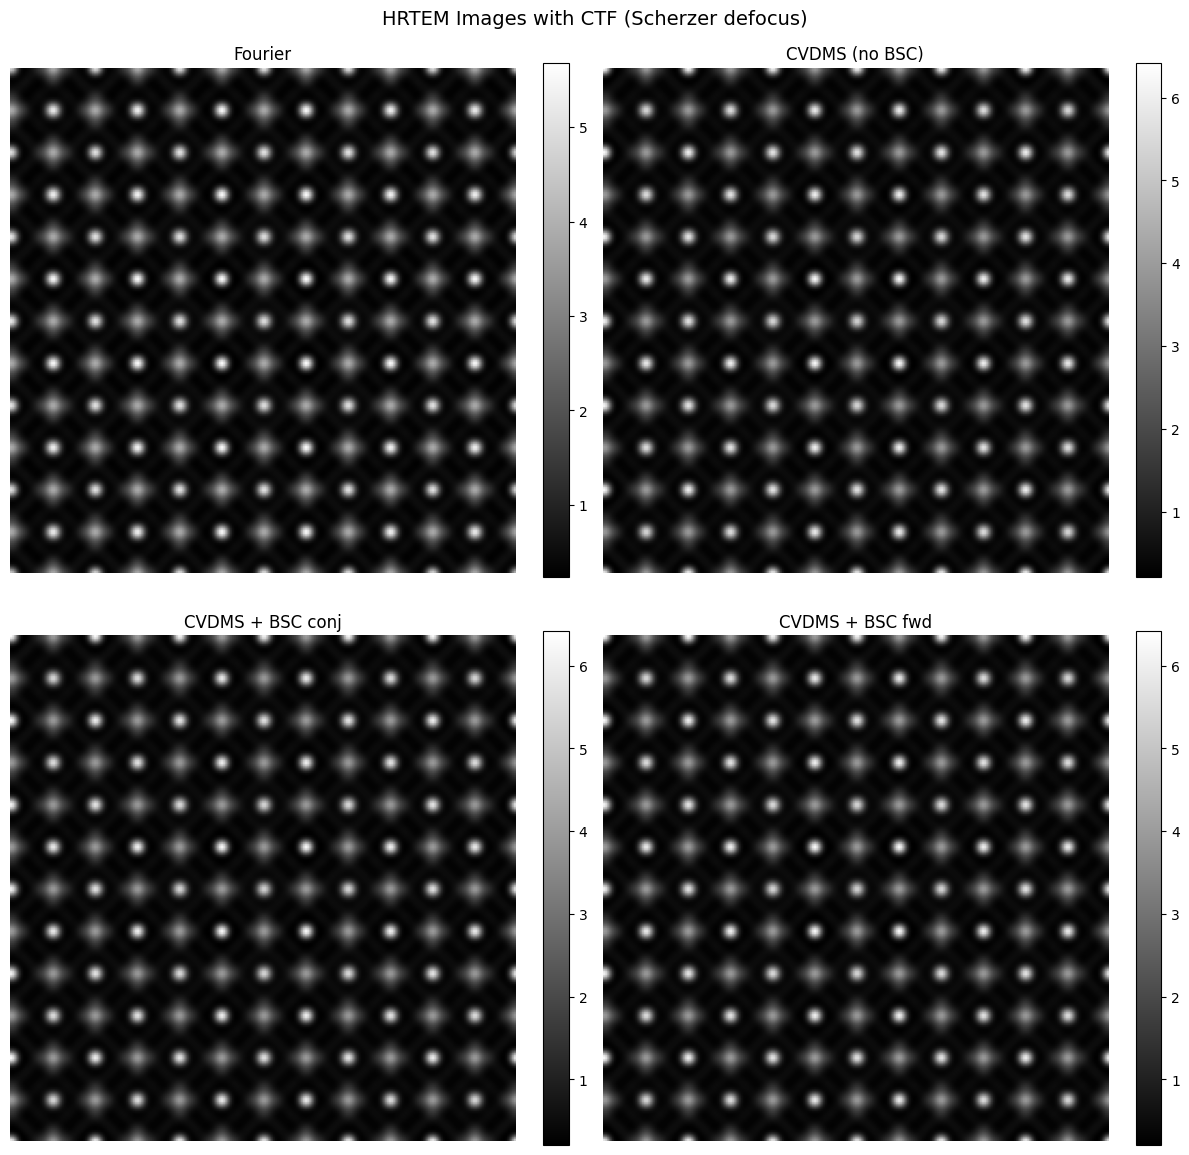

In [12]:
# CTF parameters
Cs = -8e-6 * 1e10  # -8 μm in Å
Cc = 1.2e-3 * 1e10  # 1.2 mm chromatic aberration in Å
energy_spread = 0.35  # eV standard deviation
focal_spread = Cc * energy_spread / plane_wave.energy

# Create CTF
ctf = CTF(
    Cs=Cs,
    energy=plane_wave.energy,
    defocus="scherzer",
    semiangle_cutoff=25,  # mrad
    focal_spread=focal_spread,
)

print(f"Scherzer defocus: {ctf.defocus:.2f} Å")
print(f"Crossover angle: {ctf.crossover_angle:.2f} mrad")
print(f"Point resolution: {ctf.point_resolution:.2f} Å")
print(f"Focal spread: {focal_spread:.2f} Å")

def to_numpy(arr):
    """Convert CuPy array to CPU numpy if needed."""
    if hasattr(arr, 'get'):
        return arr.get()
    return arr

# Apply CTF and compute intensity for all methods
images = {}
for name, wave in methods:
    img = wave.apply_ctf(ctf).intensity()
    images[name] = to_numpy(img.array[-1])

# Visualize HRTEM images
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

for (name, img_arr), ax in zip(images.items(), axes.ravel()):
    im = ax.imshow(img_arr, cmap="gray")
    ax.set_title(f"{name}")
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046)

fig.suptitle("HRTEM Images with CTF (Scherzer defocus)", fontsize=14)
plt.tight_layout()
plt.show()

In [13]:
_cleanup_gpu()

## 10. Frozen Phonon HRTEM

Now compute the HRTEM image with frozen phonon averaging, comparing
three methods:
  - **Fourier multislice** (reference, the conventional method)
  - **CVDMS** (no backscattering)
  - **CVDMS + BSC** (with backscattering correction)

The frozen phonon ensemble averages over multiple atomic configurations,
accounting for thermal diffuse scattering. This produces more realistic
HRTEM images.

In [14]:
print("Computing frozen phonon HRTEM with Fourier multislice (reference)...")
exit_wave_fp_fourier = plane_wave.multislice(
    potential,
    algorithm=FourierMultislice(),
    lazy=False,
)
print(f"Fourier FP ensemble shape: {exit_wave_fp_fourier.shape}")

# FP average: CTF → intensity per config → mean (incoherent)
# Apply CTF to all exit planes, then select the last one for display
img_fp_fourier_ensemble = exit_wave_fp_fourier.apply_ctf(ctf).intensity().mean(0)
img_fp_fourier = to_numpy(img_fp_fourier_ensemble.array[-1])
amp_fp_fourier = float(np.abs(exit_wave_fp_fourier.array[:, -1, :, :]).mean())

# Fourier diffraction: |FFT(ψ_i)|² → mean
fp_fourier_last = exit_wave_fp_fourier._array[:, -1]  # (num_configs, H, W) on GPU
dp_fourier = cp.fft.fftshift(cp.abs(cp.fft.fft2(fp_fourier_last)) ** 2, axes=(1, 2))
dp_fourier_mean = dp_fourier.mean(0)

# Move Fourier FP GPU data to CPU and free
dp_fourier_mean_cpu = to_numpy(dp_fourier_mean)
del exit_wave_fp_fourier, fp_fourier_last, dp_fourier
_cleanup_gpu()

print(f"Fourier FP exit amplitude (last plane): {amp_fp_fourier:.6f}")
print(f"Fourier FP diffraction shape: {dp_fourier_mean.shape}")

Computing frozen phonon HRTEM with Fourier multislice (reference)...
Fourier FP ensemble shape: (8, 5, 235, 235)
Fourier FP exit amplitude (last plane): 0.939015
Fourier FP diffraction shape: (235, 235)


In [15]:
print("Computing frozen phonon HRTEM with CVDMS (no BSC)...")
exit_wave_fp = plane_wave.multislice(
    potential,
    algorithm=CVDMSMultislice(
        convergence_threshold=convergence_threshold,
        order=1,
    ),
    lazy=False,
)
print(f"FP ensemble shape: {exit_wave_fp.shape}")

# Correct frozen phonon HRTEM: apply CTF + intensity per config, then average
# intensities (incoherent sum). This accounts for thermal diffuse scattering.
#   WRONG: exit_wave.mean(0) → CTF → |·|²  (coherent avg of exit waves)
#   RIGHT: for each config ψ_i → CTF → |ψ_i * CTF|² → mean over i (incoherent avg)
img_fp_ensemble = exit_wave_fp.apply_ctf(ctf).intensity().mean(0)
img_fp = to_numpy(img_fp_ensemble.array[-1])

# Keep exit wave mean for BSC reference analysis only (coherent average)
exit_wave_fp_mean = exit_wave_fp.mean(0)
print(f"Mean exit wave shape: {exit_wave_fp_mean.shape}")

# Compute FP (no BSC) diffraction before freeing GPU memory
# Incoherent average: |FFT(ψ_i)|² → mean
print("Computing FP (no BSC) diffraction patterns...")
fp_exit_last = exit_wave_fp._array[:, -1]  # (num_configs, H, W) on GPU
diffraction_patterns = cp.abs(cp.fft.fft2(fp_exit_last)) ** 2
diffraction_patterns = cp.fft.fftshift(diffraction_patterns, axes=(1, 2))
diffraction_pattern_mean = diffraction_patterns.mean(0)

sampling_val = float(potential.sampling[0])
ny, nx = diffraction_pattern_mean.shape
kx = cp.fft.fftshift(cp.fft.fftfreq(nx, d=sampling_val))
ky = cp.fft.fftshift(cp.fft.fftfreq(ny, d=sampling_val))
k_max = float(cp.sqrt(kx**2 + ky[:, None]**2).max())
k_max_np = k_max  # for log scale plots

# Move results to CPU to free GPU memory
diffraction_pattern_mean_np = float(cp.sum(diffraction_pattern_mean))
diffraction_patterns_cpu = to_numpy(diffraction_patterns)
diffraction_pattern_mean_cpu = to_numpy(diffraction_pattern_mean)

print(f"Diffraction pattern shape: {diffraction_pattern_mean.shape}")
print(f"Max spatial frequency: {k_max:.4f} Å⁻¹")

# Free large GPU arrays before FP+BSC section
print("Freeing GPU memory before FP+BSC...")
# Save exit wave stats before deletion for later comparison
amp_fp_cvdms = float(cp.abs(exit_wave_fp._array[:, -1, :, :]).mean())
del exit_wave_fp, fp_exit_last, diffraction_patterns, diffraction_pattern_mean
del exit_wave_fp_mean, kx, ky
_cleanup_gpu()

Computing frozen phonon HRTEM with CVDMS (no BSC)...
FP ensemble shape: (8, 5, 235, 235)
Mean exit wave shape: (5, 235, 235)
Computing FP (no BSC) diffraction patterns...
Diffraction pattern shape: (235, 235)
Max spatial frequency: 7.0620 Å⁻¹
Freeing GPU memory before FP+BSC...


In [ ]:
print("Computing frozen phonon HRTEM with CVDMS + BSC...")
result_fp_bsc = plane_wave.multislice(
    potential,
    algorithm=CVDMSMultislice(
        backscattering=True,
        calculate_backscattered=True,
        back_prop_mode="conj",
        convergence_threshold=convergence_threshold,
        order=1,
    ),
    return_backscattered=True,
    lazy=False,
)
exit_wave_fp_bsc = result_fp_bsc[0]     # forward exit wave (num_configs, num_ep, H, W)
bsc_wave_fp = result_fp_bsc[-1]          # BSC wave (num_configs, num_ep, H, W)
print(f"FP+BSC exit shape: {exit_wave_fp_bsc.shape}")
print(f"FP BSC wave shape: {bsc_wave_fp.shape}")
print(f"FP BSC max amplitude (all configs): {float(np.abs(bsc_wave_fp.array).max()):.4e}")

# Correct HRTM: intensity per config → average → select last exit plane
img_fp_bsc_ensemble = exit_wave_fp_bsc.apply_ctf(ctf).intensity().mean(0)
img_fp_bsc = to_numpy(img_fp_bsc_ensemble.array[-1])

# Keep exit wave mean for reference
exit_wave_fp_bsc_mean = exit_wave_fp_bsc.mean(0)

In [17]:
_cleanup_gpu()

## 11. Frozen Phonon Coherent Diffraction

Compute the parallel-beam coherent diffraction pattern from each frozen phonon
configuration. The diffraction pattern is the squared amplitude of the Fourier
transform of the exit wave:

$$I_{\text{diff}}(\mathbf{k}) = |\mathcal{FT}[\psi_{\text{exit}}](\mathbf{k})|^2$$

For frozen phonon averaging, we average the **intensities** (incoherent sum),
which accounts for thermal diffuse scattering (TDS).

The no-BSC diffraction was pre-computed before the FP+BSC section to manage
GPU memory. Here we compute only the BSC diffraction from the new result.

In [18]:
# Compute BSC diffraction from exit_wave_fp_bsc
print("Computing FP + BSC diffraction patterns...")
fp_bsc_exit_last = exit_wave_fp_bsc._array[:, -1]
dp_bsc = cp.abs(cp.fft.fft2(fp_bsc_exit_last)) ** 2
dp_bsc = cp.fft.fftshift(dp_bsc, axes=(1, 2))
dp_bsc_mean = dp_bsc.mean(0)
dp_bsc_mean_sum = float(cp.sum(dp_bsc_mean))
print(f"BSC diffraction shape: {dp_bsc_mean.shape}")

Computing FP + BSC diffraction patterns...
BSC diffraction shape: (235, 235)


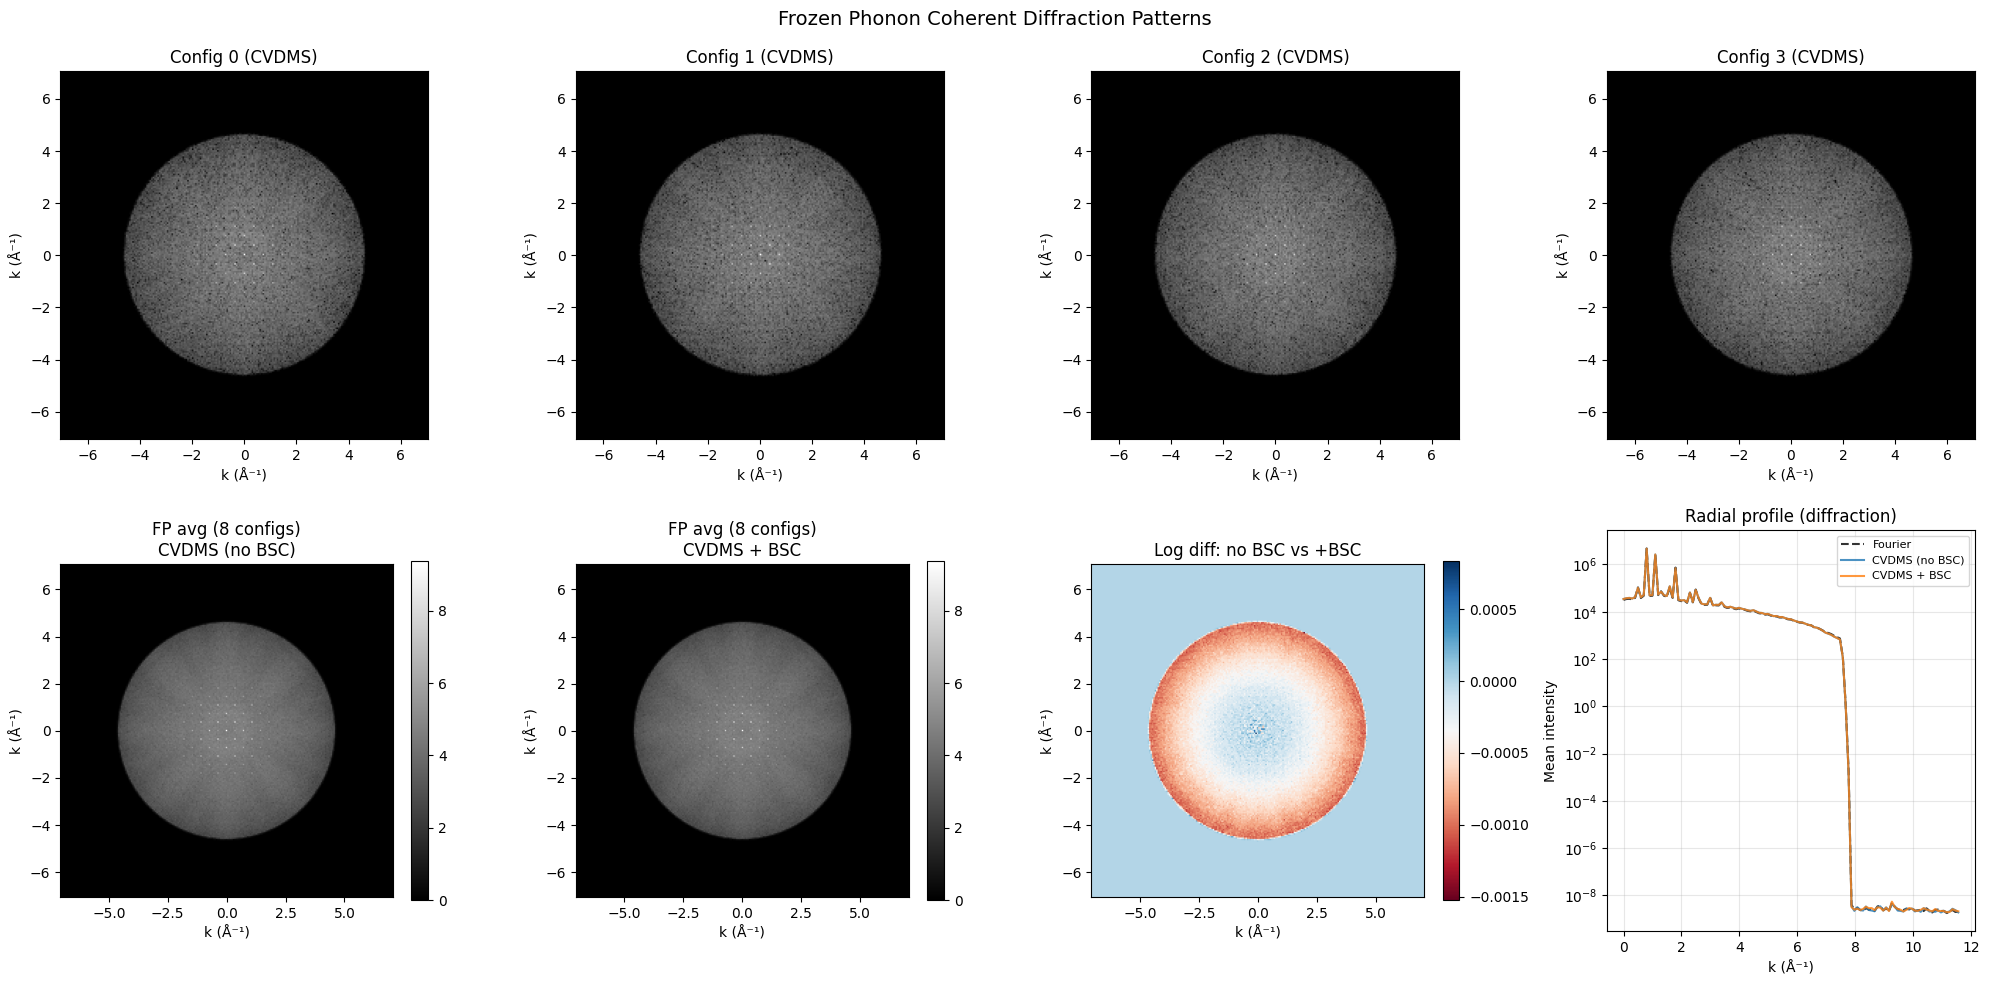

In [19]:
# Display individual configuration diffraction patterns and ensemble average
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

# Show individual no-BSC config patterns (from pre-computed CPU data)
num_show = min(4, frozen_phonons.num_configs)
for i in range(num_show):
    dp_i = np.log10(diffraction_patterns_cpu[i] + 1)
    axes[0, i].imshow(dp_i, cmap="gray", extent=[-k_max_np, k_max_np, -k_max_np, k_max_np])
    axes[0, i].set_title(f"Config {i} (CVDMS)")
    axes[0, i].set_xlabel("k (Å⁻¹)")
    axes[0, i].set_ylabel("k (Å⁻¹)")

# Ensemble averaged patterns
im4 = axes[1, 0].imshow(np.log10(diffraction_pattern_mean_cpu + 1), cmap="gray",
                         extent=[-k_max_np, k_max_np, -k_max_np, k_max_np])
axes[1, 0].set_title(f"FP avg ({frozen_phonons.num_configs} configs)\nCVDMS (no BSC)")
axes[1, 0].set_xlabel("k (Å⁻¹)")
axes[1, 0].set_ylabel("k (Å⁻¹)")
plt.colorbar(im4, ax=axes[1, 0], fraction=0.046)

dp_bsc_mean_arr = to_numpy(cp.log10(dp_bsc_mean + 1))
im5 = axes[1, 1].imshow(dp_bsc_mean_arr, cmap="gray",
                         extent=[-k_max_np, k_max_np, -k_max_np, k_max_np])
axes[1, 1].set_title(f"FP avg ({frozen_phonons.num_configs} configs)\nCVDMS + BSC")
axes[1, 1].set_xlabel("k (Å⁻¹)")
axes[1, 1].set_ylabel("k (Å⁻¹)")
plt.colorbar(im5, ax=axes[1, 1], fraction=0.046)

# Difference between no-BSC and BSC diffraction patterns
dp_diff = np.log10(diffraction_pattern_mean_cpu + 1) - to_numpy(cp.log10(dp_bsc_mean + 1))
im6 = axes[1, 2].imshow(dp_diff, cmap="RdBu", extent=[-k_max_np, k_max_np, -k_max_np, k_max_np])
axes[1, 2].set_title("Log diff: no BSC vs +BSC")
axes[1, 2].set_xlabel("k (Å⁻¹)")
axes[1, 2].set_ylabel("k (Å⁻¹)")
plt.colorbar(im6, ax=axes[1, 2], fraction=0.046)

# Radial profile comparison (including Fourier reference)
ny, nx = diffraction_pattern_mean_cpu.shape
center_y, center_x = ny // 2, nx // 2
radial_bins = np.arange(0, min(ny, nx) // 2, 1)
radial_profile_fourier = np.zeros(len(radial_bins))
radial_profile_nobsc = np.zeros(len(radial_bins))
radial_profile_bsc = np.zeros(len(radial_bins))
y, x = np.ogrid[:ny, :nx]
for i, r in enumerate(radial_bins):
    outer = ((y - center_y) ** 2 + (x - center_x) ** 2) <= (r + 1) ** 2
    inner = ((y - center_y) ** 2 + (x - center_x) ** 2) <= r ** 2
    mask = outer & ~inner
    radial_profile_fourier[i] = float(np.mean(dp_fourier_mean_cpu[mask]))
    radial_profile_nobsc[i] = float(np.mean(diffraction_pattern_mean_cpu[mask]))
    radial_profile_bsc[i] = float(to_numpy(cp.mean(dp_bsc_mean[mask])))

ax7 = axes[1, 3]
ax7.semilogy(radial_bins * sampling_val, radial_profile_fourier,
             label="Fourier", alpha=0.8, linestyle="--", color="black")
ax7.semilogy(radial_bins * sampling_val, radial_profile_nobsc,
             label="CVDMS (no BSC)", alpha=0.8)
ax7.semilogy(radial_bins * sampling_val, radial_profile_bsc,
             label="CVDMS + BSC", alpha=0.8)
ax7.set_xlabel("k (Å⁻¹)")
ax7.set_ylabel("Mean intensity")
ax7.set_title("Radial profile (diffraction)")
ax7.legend(fontsize=8)
ax7.grid(True, alpha=0.3)

fig.suptitle("Frozen Phonon Coherent Diffraction Patterns", fontsize=14)
plt.tight_layout()
plt.show()

In [20]:
# Quantitative comparison
print("Diffraction pattern comparison (FP averaged):")
print(f"  Fourier total intensity:               {float(dp_fourier_mean_cpu.sum()):.4e}")
print(f"  CVDMS (no BSC) total intensity:         {diffraction_pattern_mean_np:.4e}")
print(f"  CVDMS + BSC total intensity:            {dp_bsc_mean_sum:.4e}")

# FP-HRTEM image comparison
print()
print("=== FP-Averaged HRTEM Image Comparison ===")
img_fp_np = img_fp
img_fp_bsc_np = img_fp_bsc
img_fp_fourier_np = img_fp_fourier

print(f"Fourier:   mean={img_fp_fourier_np.mean():.6f}  std={img_fp_fourier_np.std():.6f}")
print(f"CVDMS:     mean={img_fp_np.mean():.6f}  std={img_fp_np.std():.6f}")
print(f"CVDMS+BSC: mean={img_fp_bsc_np.mean():.6f}  std={img_fp_bsc_np.std():.6f}")
ncc_fc = np.corrcoef(img_fp_fourier_np.ravel(), img_fp_np.ravel())[0, 1]
ncc_fb = np.corrcoef(img_fp_fourier_np.ravel(), img_fp_bsc_np.ravel())[0, 1]
ncc_cb = np.corrcoef(img_fp_np.ravel(), img_fp_bsc_np.ravel())[0, 1]
print(f"NCC(Fourier, CVDMS):     {ncc_fc:.6f}")
print(f"NCC(Fourier, CVDMS+BSC): {ncc_fb:.6f}")
print(f"NCC(CVDMS, CVDMS+BSC):   {ncc_cb:.6f}")

# FP exit amplitude comparison
# amp_fp_fourier and amp_fp_cvdms were saved before GPU cleanup above
amp_fp_bsc_val = float(cp.abs(exit_wave_fp_bsc._array[:, -1, :, :]).mean())
print()
print("FP exit amplitude (last plane):")
print(f"  Fourier:   {amp_fp_fourier:.6f}")
print(f"  CVDMS:     {amp_fp_cvdms:.6f}")
print(f"  CVDMS+BSC: {amp_fp_bsc_val:.6f}")

Diffraction pattern comparison (FP averaged):
  Fourier total intensity:               2.9845e+09
  CVDMS (no BSC) total intensity:         3.0346e+09
  CVDMS + BSC total intensity:            3.0347e+09

=== FP-Averaged HRTEM Image Comparison ===
Fourier:   mean=0.930171  std=0.593597
CVDMS:     mean=0.945461  std=0.594086
CVDMS+BSC: mean=0.945481  std=0.594111
NCC(Fourier, CVDMS):     0.999078
NCC(Fourier, CVDMS+BSC): 0.999077
NCC(CVDMS, CVDMS+BSC):   1.000000

FP exit amplitude (last plane):
  Fourier:   0.939015
  CVDMS:     0.947470
  CVDMS+BSC: 0.947487


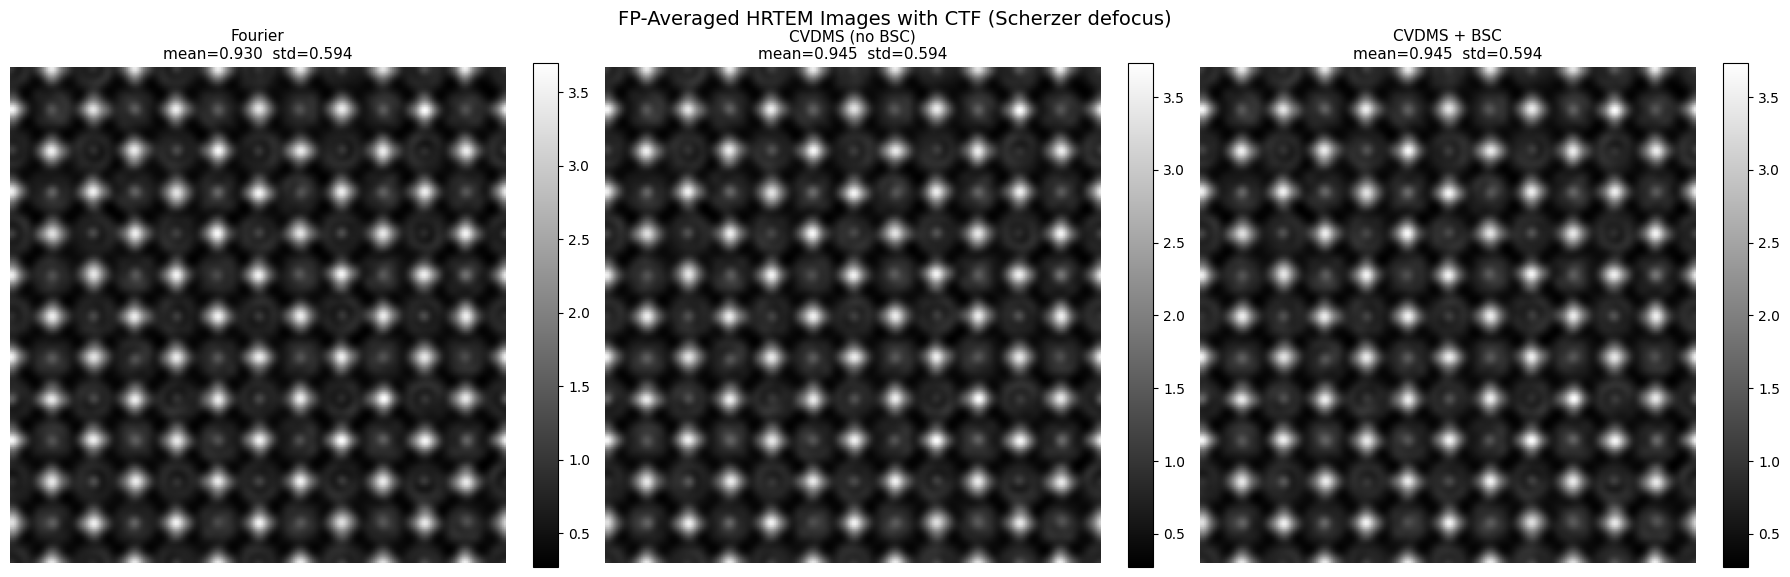

In [21]:
# Visualize FP-averaged HRTEM image comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
methods_fp = [
    ("Fourier", img_fp_fourier_np),
    ("CVDMS (no BSC)", img_fp_np),
    ("CVDMS + BSC", img_fp_bsc_np),
]
for (name, img_arr), ax in zip(methods_fp, axes):
    im = ax.imshow(img_arr, cmap="gray")
    ax.set_title(f"{name}\nmean={img_arr.mean():.3f}  std={img_arr.std():.3f}", fontsize=11)
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle("FP-Averaged HRTEM Images with CTF (Scherzer defocus)", fontsize=14)
plt.tight_layout()
plt.show()

## 12. Backscattering Diffraction (FP Ensemble)

Compute the diffraction pattern of the **backscattered wave** from the frozen phonon
ensemble. For each FP config, we compute |FFT(BSC)|² at the entrance surface (EP 0),
then average the intensities across configs (incoherent sum). This is the same
procedure used for forward diffraction averaging.

The BSC diffraction is compared with the FP-averaged forward diffraction
to quantify the BSC loss channel for each scattering angle.

In [ ]:
print("Computing FP-averaged BSC diffraction...")

# BSC at entrance surface (EP 0) for all FP configs: (num_configs, H, W)
bsc_fp_ep0 = bsc_wave_fp.array[:, 0, :, :]

# |FFT|² per config, then average (incoherent)
bsc_dp_configs = cp.abs(cp.fft.fft2(bsc_fp_ep0)) ** 2
bsc_dp_configs = cp.fft.fftshift(bsc_dp_configs, axes=(1, 2))
bsc_dp_mean = bsc_dp_configs.mean(0)  # FP-averaged
bsc_dp_std = bsc_dp_configs.std(0)    # config-to-config variation

print(f"BSC diffraction shape: {bsc_dp_mean.shape}")
print(f"BSC config-to-config std/mean ratio: {float(cp.mean(bsc_dp_std / (bsc_dp_mean + 1e-30))):.4f}")

# Ratio map: BSC / forward diffraction (FP-averaged)
eps = 1e-30
ratio_map = np.log10(to_numpy(bsc_dp_mean) + eps) - np.log10(diffraction_pattern_mean_cpu + eps)

# Per-config BSC amplitudes for statistics
bsc_amp_per_config = [float(cp.abs(bsc_wave_fp.array[i, 0, :, :]).max()) for i in range(frozen_phonons.num_configs)]
print(f"BSC max amplitude per config: mean={np.mean(bsc_amp_per_config):.4e}  std={np.std(bsc_amp_per_config):.4e}")

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# BSC diffraction (log scale, FP-averaged)
bsc_dp_log = to_numpy(cp.log10(bsc_dp_mean + 1))
im0 = axes[0].imshow(bsc_dp_log, cmap="inferno",
                     extent=[-k_max_np, k_max_np, -k_max_np, k_max_np])
axes[0].set_title(f"BSC diffraction (FP avg, {frozen_phonons.num_configs} configs)\n(entrance surface)")
axes[0].set_xlabel("k (Å⁻¹)")
axes[0].set_ylabel("k (Å⁻¹)")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

# Forward diffraction (log scale) for comparison
dp_fwd_log = np.log10(diffraction_pattern_mean_cpu + 1)
im1 = axes[1].imshow(dp_fwd_log, cmap="inferno",
                     extent=[-k_max_np, k_max_np, -k_max_np, k_max_np])
axes[1].set_title(f"Forward diffraction (FP avg)\n({frozen_phonons.num_configs} configs)")
axes[1].set_xlabel("k (Å⁻¹)")
axes[1].set_ylabel("k (Å⁻¹)")
plt.colorbar(im1, ax=axes[1], fraction=0.046)

# Ratio: log10(BSC / forward)
vlim = max(abs(ratio_map.min()), abs(ratio_map.max()))
im2 = axes[2].imshow(ratio_map, cmap="RdBu", vmin=-vlim, vmax=vlim,
                     extent=[-k_max_np, k_max_np, -k_max_np, k_max_np])
axes[2].set_title("log₁₀(BSC / forward)")
axes[2].set_xlabel("k (Å⁻¹)")
axes[2].set_ylabel("k (Å⁻¹)")
plt.colorbar(im2, ax=axes[2], fraction=0.046)

# Radial profiles (FP-averaged for both)
hp_y, hp_x = diffraction_pattern_mean_cpu.shape[0] // 2, diffraction_pattern_mean_cpu.shape[1] // 2
radial_bins = np.arange(0, min(diffraction_pattern_mean_cpu.shape) // 2, 1)
radial_fwd = np.zeros(len(radial_bins))
radial_bsc = np.zeros(len(radial_bins))
bsc_dp_mean_cpu = to_numpy(bsc_dp_mean)
for i, r in enumerate(radial_bins):
    y, x = np.ogrid[:diffraction_pattern_mean_cpu.shape[0], :diffraction_pattern_mean_cpu.shape[1]]
    outer = ((y - hp_y) ** 2 + (x - hp_x) ** 2) <= (r + 1) ** 2
    inner = ((y - hp_y) ** 2 + (x - hp_x) ** 2) <= r ** 2
    mask = outer & ~inner
    radial_fwd[i] = float(np.mean(diffraction_pattern_mean_cpu[mask]))
    radial_bsc[i] = float(np.mean(bsc_dp_mean_cpu[mask]))

ax3 = axes[3]
ax3.semilogy(radial_bins * sampling_val, radial_fwd, label="Forward (FP avg)", alpha=0.8)
ax3.semilogy(radial_bins * sampling_val, radial_bsc, label="BSC (FP avg)", alpha=0.8)
ax3.set_xlabel("k (Å⁻¹)")
ax3.set_ylabel("Mean intensity")
ax3.set_title("Radial profile")
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

fig.suptitle("Backscattering Diffraction (FP Ensemble) vs Forward Diffraction", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Quantitative comparison (FP-averaged)
print("BSC vs forward diffraction (FP-averaged):")
print(f"  Forward total intensity (FP avg, {frozen_phonons.num_configs} configs): {diffraction_pattern_mean_np:.4e}")
print(f"  BSC total intensity (FP avg, {frozen_phonons.num_configs} configs):    {float(cp.sum(bsc_dp_mean)):.4e}")
bsc_ratio = float(cp.sum(bsc_dp_mean) / diffraction_pattern_mean_np)
print(f"  BSC / Forward ratio:     {bsc_ratio:.6f}  ({bsc_ratio*100:.4f}%)")

print()
print("BSC config-to-config statistics (max amplitude at entrance surface):")
for i, amp in enumerate(bsc_amp_per_config):
    print(f"  Config {i}: {amp:.4e}")
print(f"  Mean: {np.mean(bsc_amp_per_config):.4e}  ±  {np.std(bsc_amp_per_config):.4e}")

## 14. Compare Frozen Phonon Results (HRTEM)

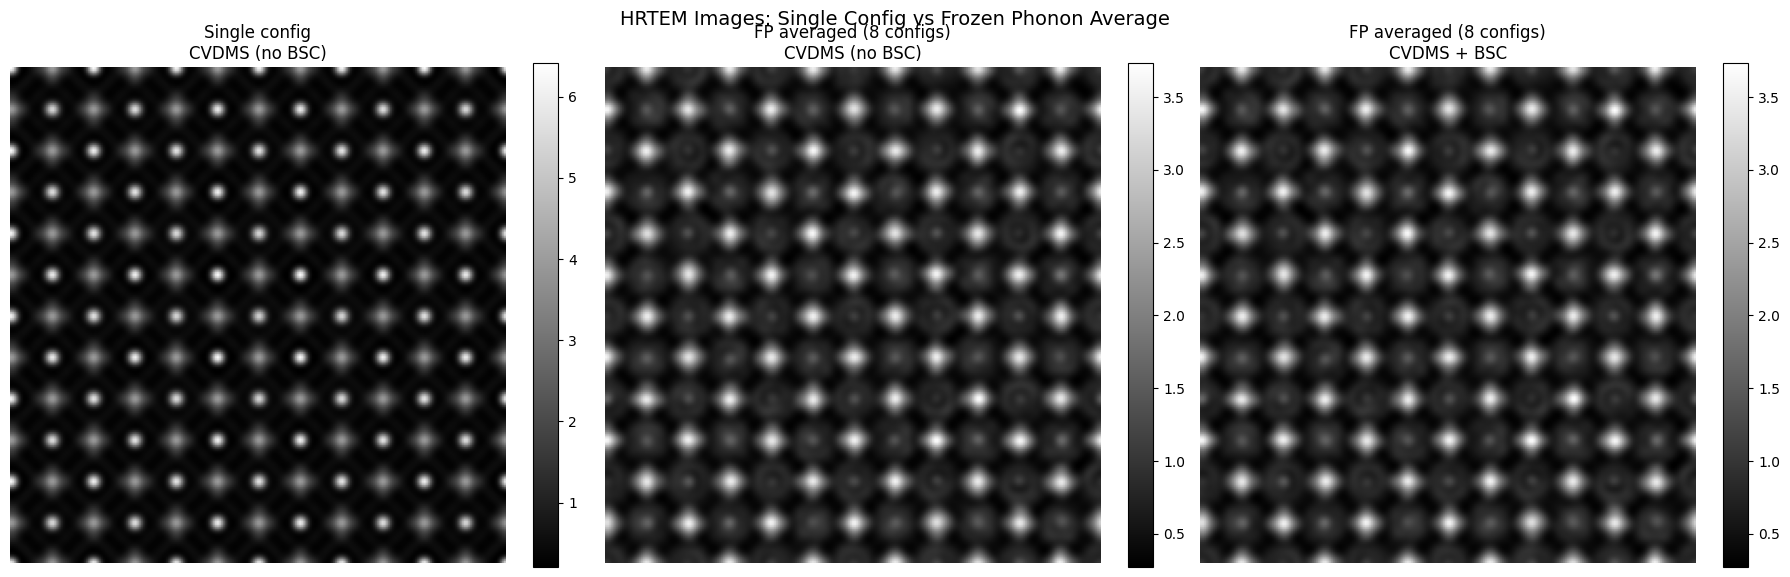

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Single config CVDMS
im0 = axes[0].imshow(images["CVDMS (no BSC)"], cmap="gray")
axes[0].set_title("Single config\nCVDMS (no BSC)")
axes[0].axis("off")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

# FP averaged CVDMS
img_fp_arr = img_fp
im1 = axes[1].imshow(img_fp_arr, cmap="gray")
axes[1].set_title(f"FP averaged ({frozen_phonons.num_configs} configs)\nCVDMS (no BSC)")
axes[1].axis("off")
plt.colorbar(im1, ax=axes[1], fraction=0.046)

# FP averaged CVDMS + BSC
img_fp_bsc_arr = img_fp_bsc
im2 = axes[2].imshow(img_fp_bsc_arr, cmap="gray")
axes[2].set_title(f"FP averaged ({frozen_phonons.num_configs} configs)\nCVDMS + BSC")
axes[2].axis("off")
plt.colorbar(im2, ax=axes[2], fraction=0.046)

fig.suptitle("HRTEM Images: Single Config vs Frozen Phonon Average", fontsize=14)
plt.tight_layout()
plt.show()

## 15. Backscattered Wave Analysis (FP Ensemble)

The backscattered wave at the entrance surface provides information about
electrons that were backscattered within the specimen. We analyze the
FP-averaged BSC amplitude, phase, and compare with single-config results.

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

# FP-averaged BSC at entrance surface (EP 0)
bsc_fp_ep0_mean = bsc_wave_fp.array[:, 0, :, :].mean(0)  # coherent avg across configs
bsc_fp_amp = to_numpy(cp.abs(bsc_fp_ep0_mean))
bsc_fp_phase = to_numpy(cp.angle(bsc_fp_ep0_mean))

# Config-to-config std of BSC amplitude
bsc_fp_amp_per_config = cp.abs(bsc_wave_fp.array[:, 0, :, :])  # (configs, H, W)
bsc_fp_amp_std = to_numpy(bsc_fp_amp_per_config.std(0))

# Single config BSC (for comparison)
bsc_single_amp = to_numpy(np.abs(bsc_wave_conj.array[0]))
bsc_single_phase = to_numpy(np.angle(bsc_wave_conj.array[0]))

# Row 1: FP-averaged BSC
im1 = axes[0, 0].imshow(bsc_fp_amp, cmap="viridis")
axes[0, 0].set_title(f"BSC Amplitude (FP avg, {frozen_phonons.num_configs} configs)")
axes[0, 0].axis("off")
plt.colorbar(im1, ax=axes[0, 0], fraction=0.046)

im2 = axes[0, 1].imshow(bsc_fp_phase, cmap="RdBu", vmin=-np.pi, vmax=np.pi)
axes[0, 1].set_title(f"BSC Phase (FP avg, {frozen_phonons.num_configs} configs)")
axes[0, 1].axis("off")
plt.colorbar(im2, ax=axes[0, 1], fraction=0.046)

# BSC config-to-config std
im3 = axes[0, 2].imshow(bsc_fp_amp_std, cmap="plasma")
axes[0, 2].set_title("BSC Amplitude std\n(config-to-config)")
axes[0, 2].axis("off")
plt.colorbar(im3, ax=axes[0, 2], fraction=0.046)

# FP BSC Fourier spectrum
bsc_fft_fp = np.fft.fftshift(np.fft.fft2(bsc_fp_amp))
im4 = axes[0, 3].imshow(np.log10(np.abs(bsc_fft_fp) + 1), cmap="gray")
axes[0, 3].set_title("BSC Log-power spectrum\n(FP avg)")
axes[0, 3].axis("off")
plt.colorbar(im4, ax=axes[0, 3], fraction=0.046)

# Row 2: Single config comparison + BSC at different depths (FP avg)
im5 = axes[1, 0].imshow(bsc_single_amp, cmap="viridis")
axes[1, 0].set_title("BSC Amplitude (single config)\n(for reference)")
axes[1, 0].axis("off")
plt.colorbar(im5, ax=axes[1, 0], fraction=0.046)

# Diff: FP avg vs single config
diff_amp = np.abs(bsc_fp_amp - bsc_single_amp)
im6 = axes[1, 1].imshow(diff_amp, cmap="plasma")
axes[1, 1].set_title(f"|FP avg - single config|\nmax={diff_amp.max():.2e}")
axes[1, 1].axis("off")
plt.colorbar(im6, ax=axes[1, 1], fraction=0.046)

# BSC at different exit planes (FP avg)
bsc_fp_mid = to_numpy(cp.abs(bsc_wave_fp.array[:, len(bsc_wave_fp) // 2, :, :]).mean(0))
bsc_fp_last = to_numpy(cp.abs(bsc_wave_fp.array[:, -1, :, :]).mean(0))

im7 = axes[1, 2].imshow(bsc_fp_mid, cmap="viridis")
axes[1, 2].set_title(f"BSC Amplitude at EP {len(bsc_wave_fp) // 2}\n(mid-depth, FP avg)")
axes[1, 2].axis("off")
plt.colorbar(im7, ax=axes[1, 2], fraction=0.046)

im8 = axes[1, 3].imshow(bsc_fp_last, cmap="viridis")
axes[1, 3].set_title("BSC Amplitude at final EP\n(bottom surface, FP avg)")
axes[1, 3].axis("off")
plt.colorbar(im8, ax=axes[1, 3], fraction=0.046)

fig.suptitle("Backscattered Wave Analysis — FP Ensemble", fontsize=14)
plt.tight_layout()
plt.show()

## 16. BSC Depth Profile

The `return_backscattered=True` option returns the backscattered wave at
each exit plane. With default `exit_planes` (only final exit plane), we get
the total backscattered wave at the entrance surface.
For a depth-resolved analysis, set `exit_planes` to an integer > 0.

In [ ]:
# Depth profile: |BSC| per config and FP-averaged at each exit plane
num_ep = bsc_wave_fp.shape[0]
num_configs = bsc_wave_fp.shape[1] if len(bsc_wave_fp.shape) > 3 else frozen_phonons.num_configs

# Per-config depth profiles
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot per-config lines
for i in range(frozen_phonons.num_configs):
    profile_i = [float(cp.abs(bsc_wave_fp.array[i, ep, :, :]).max()) for ep in range(bsc_wave_fp.shape[1])]
    ax1.plot(range(len(profile_i)), profile_i, "o-", alpha=0.5, linewidth=1, markersize=4, label=f"Config {i}")

# FP-averaged
fp_profile = [float(cp.abs(bsc_wave_fp.array[:, ep, :, :]).mean(0).max()) for ep in range(bsc_wave_fp.shape[1])]
ax1.plot(range(len(fp_profile)), fp_profile, "o-", color="black", linewidth=2.5, markersize=8, label="FP avg")

# Single config for comparison
single_profile = [float(to_numpy(cp.abs(bsc_wave_conj._array[ep])).max()) for ep in range(len(bsc_wave_conj))]
ax1.plot(range(len(single_profile)), single_profile, "s--", color="red", linewidth=1.5, markersize=6, label="Single config")

ax1.set_xlabel("Exit Plane Index (0 = entrance surface)")
ax1.set_ylabel("Max |BSC| amplitude")
ax1.set_title("BSC Depth Profile — Per Config + FP Avg")
ax1.legend(fontsize=7)
ax1.grid(True, alpha=0.3)

# FP-averaged with std error bars
fp_mean = [float(cp.abs(bsc_wave_fp.array[:, ep, :, :]).mean()) for ep in range(bsc_wave_fp.shape[1])]
fp_max = [float(cp.abs(bsc_wave_fp.array[:, ep, :, :]).max(0).mean()) for ep in range(bsc_wave_fp.shape[1])]
fp_std = [float(cp.abs(bsc_wave_fp.array[:, ep, :, :]).max(0).std()) for ep in range(bsc_wave_fp.shape[1])]

ax2.errorbar(range(len(fp_max)), fp_max, yerr=fp_std, fmt="o-", color="steelblue",
             linewidth=2, markersize=8, capsize=4, label="Mean max |BSC| ± std")
ax2.set_xlabel("Exit Plane Index (0 = entrance surface)")
ax2.set_ylabel("|BSC| amplitude")
ax2.set_title("BSC Depth Profile — FP Avg ± Config Std")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("BSC depth profile (FP-averaged, max amplitude per exit plane):")
for ep_idx in range(len(fp_max)):
    print(f"  EP {ep_idx}: mean_max={fp_max[ep_idx]:.4e}  ±  {fp_std[ep_idx]:.2e}")

## 17. Comparison: Exit Wave Profiles

Extract line profiles through the HRTEM images for quantitative comparison.

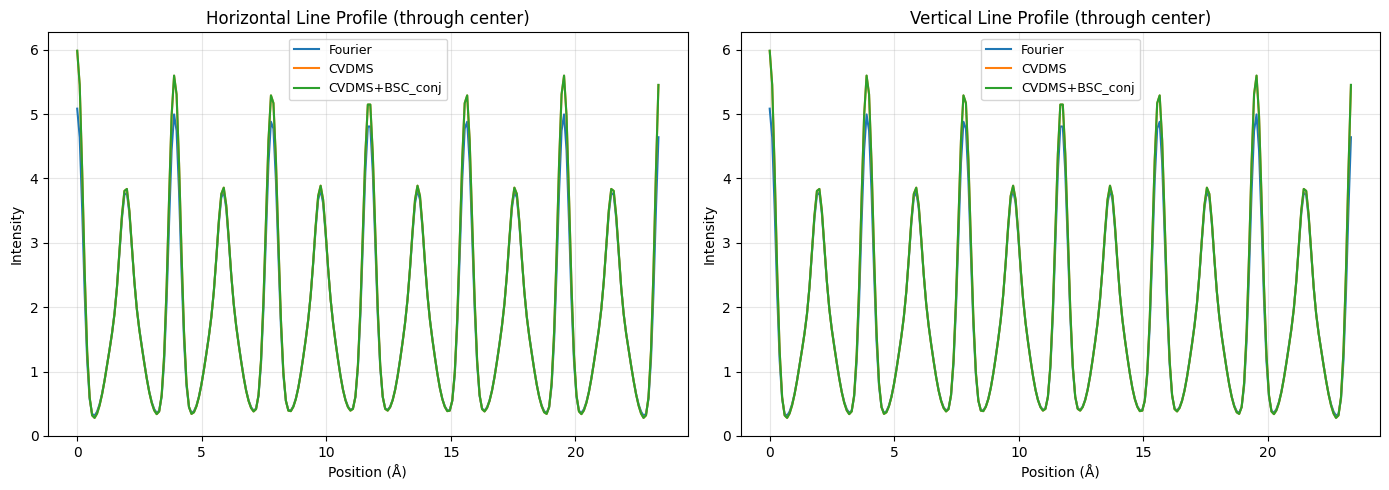

In [28]:
# Cut line profiles through center of images
def line_profile(image_array, axis=0):
    """Extract line profile through center of image."""
    ny, nx = image_array.shape[-2:]
    if axis == 0:  # horizontal line through center
        return image_array[ny // 2, :]
    else:  # vertical line through center
        return image_array[:, nx // 2]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Collect images to compare
compare_images = {
    "Fourier": images["Fourier"],
    "CVDMS": images["CVDMS (no BSC)"],
    "CVDMS+BSC_conj": images["CVDMS + BSC conj"],
}

sampling = single_potential.sampling[0]
num_pixels = compare_images["CVDMS"].shape[-1]
x_axis = np.arange(num_pixels) * sampling

for name, img_arr in compare_images.items():
    profile = line_profile(img_arr, axis=0)
    axes[0].plot(x_axis, profile, label=name, linewidth=1.5)

axes[0].set_xlabel("Position (Å)")
axes[0].set_ylabel("Intensity")
axes[0].set_title("Horizontal Line Profile (through center)")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

for name, img_arr in compare_images.items():
    profile = line_profile(img_arr, axis=1)
    axes[1].plot(x_axis, profile, label=name, linewidth=1.5)

axes[1].set_xlabel("Position (Å)")
axes[1].set_ylabel("Intensity")
axes[1].set_title("Vertical Line Profile (through center)")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 18. Summary

This notebook demonstrated:

1. **HRTEM with Fourier multislice** — standard Fourier method reference
2. **HRTEM with CVDMS (no BSC)** — real-space Taylor expansion without backscattering
3. **HRTEM with CVDMS + BSC** — full coupled-wave theory with backscattering correction
   - `back_prop_mode="conj"`: physically correct backward propagation
   - `back_prop_mode="forward"`: CGS-compatible mode for cross-validation
4. **Frozen phonon averaging** — thermal diffuse scattering via ensemble averaging
5. **CTF application** — aberration correction, aperture, partial coherence
6. **Multi-FP backscattered wave analysis** — BSC diffraction averaged across FP configs,
   config-to-config variation, depth profile with error bars, comparison with single-config BSC

### Key parameters:

| Parameter | Value |
|-----------|-------|
| Material | SrTiO₃ (100) |
| Voltage | 300 keV |
| Supercell | 6 × 6 × 30 |
| Sampling | 0.1 Å/pixel |
| Slice thickness | 1.0 Å |
| Cs | -8 μm |
| Defocus | Scherzer |
| Frozen phonon configs | 8 |
| Exit planes | 5 |

### Notes:
- The backscattering correction produces a small but measurable difference in
  the HRTEM image intensity distribution
- Frozen phonon averaging smooths out high-frequency noise and produces more
  realistic images
- The conj mode provides physically correct time-reversed backward propagation
- Multi-FP BSC analysis reveals config-to-config variation in backscattering,
  with the FP-averaged BSC providing a statistically meaningful loss channel estimate